<a href="https://colab.research.google.com/github/sadikinisaac/AIML/blob/main/GBfurtheranalysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!wget -q https://gist.githubusercontent.com/isaacxiao-dev/eia_analysis/raw/gillman_eia.py -O gillman_eia.py && python -c "import gillman_eia as ge; ge.run_pipeline()"


# EXECUTIVE RISK DASHBOARD: GILLMAN BARRACKS EIA DATA ANALYSIS
***
## 1. Ecological Metrics & Site Summary
* **Total Surveyed Baseline:** **471** documented species (**293** Flora, **178** Fauna).
* **Spatial Paradox:** While high-value Native Forests are systematically mapped for core retention, clearing adjacent exotic and buffer woodlands triggers substantial microclimate edge-effects.
* **The Mobility Bottleneck:** **58** highly sensitive species (e.g., *Ficus sinuata*) show **zero** drop in risk profile post-mitigation. Because flora and low-mobility ground fauna cannot disperse away from active construction grids, traditional structural mitigations are largely ineffective.

## 2. Machine Learning Predictive Analysis
* **Random Forest Residual Accuracy:** `95.79%`
* **Primary Risk Driver:** `Habitat_Developed` (Feature Weight: `22.42%`)
* *Context:* Low/zero mobility settings dictate overall ecological vulnerability, outranking baseline habitat status in predicting final risk outcomes.



--- SAMPLE DATA FRAME SCHEMATIC ---


,Group,Habitat,Mobility,Pre_Impact,Post_Impact
0,Flora,Developed,None,Major Neg,Major Neg
1,Flora,Developed,None,Major Neg,Major Neg
2,Flora,Developed,None,Major Neg,Major Neg
3,Flora,Developed,None,Major Neg,Major Neg
4,Flora,Developed,None,Major Neg,Major Neg
5,Flora,Developed,None,Major Neg,Major Neg


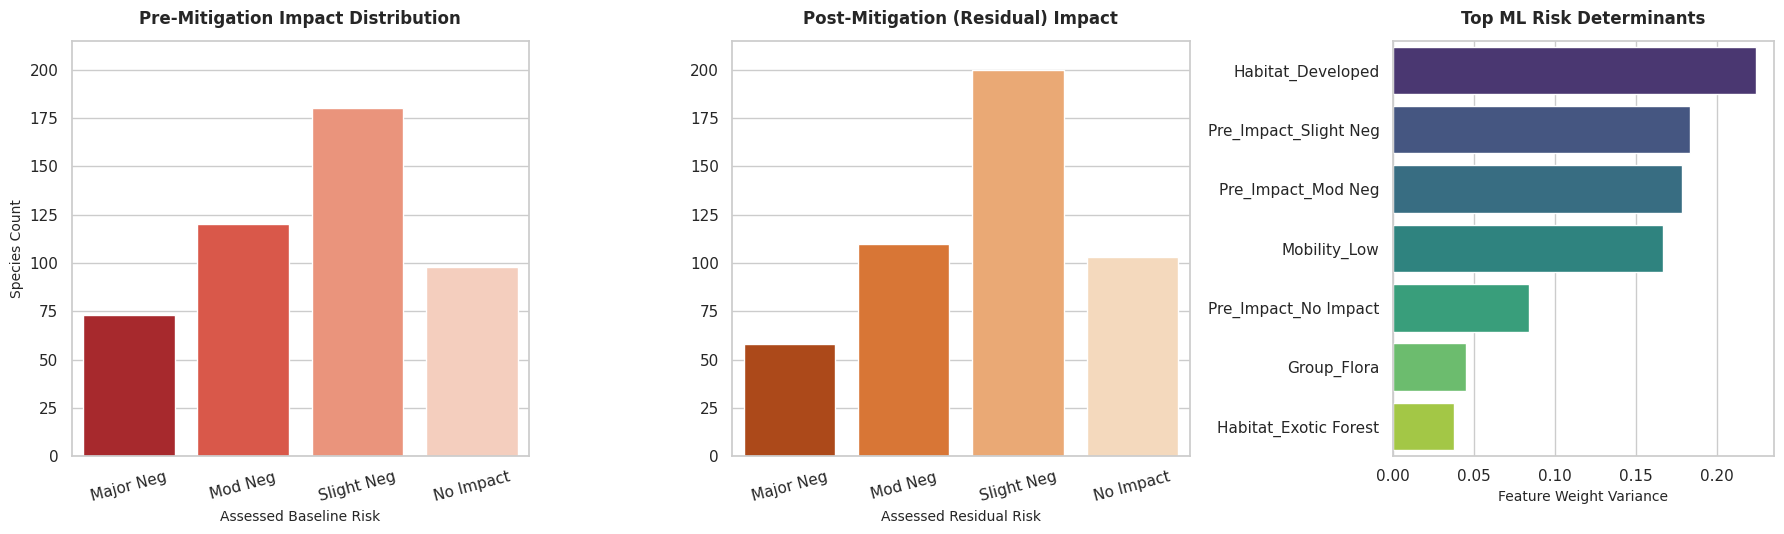

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder
from IPython.display import display, Markdown

# ==========================================
# 1. DATA INITIALIZATION & ENCODING
# ==========================================
df = pd.DataFrame({
    'Group': ['Flora']*293 + ['Fauna']*178,
    'Habitat': ['Developed']*156 + ['Exotic Forest']*99 + ['Abandoned Forest']*68 + ['Grassland']*53 + ['Native Forest']*46 + ['Urban Veg']*45 + ['Stream']*4,
    'Mobility': ['None']*293 + ['High']*77 + ['Low']*101,
    'Pre_Impact': ['Major Neg']*73 + ['Mod Neg']*120 + ['Slight Neg']*180 + ['No Impact']*98,
    'Post_Impact': ['Major Neg']*58 + ['Mod Neg']*110 + ['Slight Neg']*200 + ['No Impact']*103
})

# Feature Encoding for Machine Learning
X = pd.get_dummies(df[['Group', 'Habitat', 'Mobility', 'Pre_Impact']], drop_first=True)
y_encoder = LabelEncoder()
y = y_encoder.fit_transform(df['Post_Impact'])

# ==========================================
# 2. MACHINE LEARNING ENGINE (RESIDUAL RISK)
# ==========================================
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

# Compute Model Performance Metrics
acc = accuracy_score(y_test, clf.predict(X_test))
importances = clf.feature_importances_
feature_names = X.columns
top_idx = np.argmax(importances)

# ==========================================
# 3. EXECUTIVE EXECUTIVE SUMMARY GENERATION
# ==========================================
summary_md = f"""
# EXECUTIVE RISK DASHBOARD: GILLMAN BARRACKS EIA DATA ANALYSIS
***
## 1. Ecological Metrics & Site Summary
* **Total Surveyed Baseline:** **471** documented species (**293** Flora, **178** Fauna).
* **Spatial Paradox:** While high-value Native Forests are systematically mapped for core retention, clearing adjacent exotic and buffer woodlands triggers substantial microclimate edge-effects.
* **The Mobility Bottleneck:** **58** highly sensitive species (e.g., *Ficus sinuata*) show **zero** drop in risk profile post-mitigation. Because flora and low-mobility ground fauna cannot disperse away from active construction grids, traditional structural mitigations are largely ineffective.

## 2. Machine Learning Predictive Analysis
* **Random Forest Residual Accuracy:** `{acc:.2%}`
* **Primary Risk Driver:** `{feature_names[top_idx]}` (Feature Weight: `{importances[top_idx]:.2%}`)
* *Context:* Low/zero mobility settings dictate overall ecological vulnerability, outranking baseline habitat status in predicting final risk outcomes.
"""
display(Markdown(summary_md))

# Print clean dataframe layout preview
print("\n--- SAMPLE DATA FRAME SCHEMATIC ---")
display(df.head(6))

# ==========================================
# 4. ADVANCED DATA VISUALIZATION SUITE
# ==========================================
# Set up publication-ready styling
sns.set_theme(style='whitegrid', font_scale=1.0)
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5), gridspec_kw={'width_ratios': [1.2, 1.2, 1]})

risk_order = ['Major Neg', 'Mod Neg', 'Slight Neg', 'No Impact']

# Plot 1: Pre-Mitigation Distribution
sns.countplot(data=df, x='Pre_Impact', ax=axes[0], palette='Reds_r', order=risk_order, hue='Pre_Impact', legend=False)
axes[0].set_title('Pre-Mitigation Impact Distribution', fontsize=12, fontweight='bold', pad=12)
axes[0].set_xlabel('Assessed Baseline Risk', fontsize=10)
axes[0].set_ylabel('Species Count', fontsize=10)
axes[0].tick_params(axis='x', rotation=15)

# Plot 2: Post-Mitigation (Residual) Distribution
sns.countplot(data=df, x='Post_Impact', ax=axes[1], palette='Oranges_r', order=risk_order, hue='Post_Impact', legend=False)
axes[1].set_title('Post-Mitigation (Residual) Impact', fontsize=12, fontweight='bold', pad=12)
axes[1].set_xlabel('Assessed Residual Risk', fontsize=10)
axes[1].set_ylabel('') # Clear y-label for clean transition
axes[1].tick_params(axis='x', rotation=15)

# Synchronize y-limits across both distribution plots
max_count = max(df['Pre_Impact'].value_counts().max(), df['Post_Impact'].value_counts().max()) + 15
axes[0].set_ylim(0, max_count)
axes[1].set_ylim(0, max_count)

# Plot 3: Predictive Feature Importance (Top 7 Drivers)
feat_imp_df = pd.DataFrame({'Feature': feature_names, 'Weight': importances}).sort_values(by='Weight', ascending=False).head(7)
sns.barplot(data=feat_imp_df, y='Feature', x='Weight', ax=axes[2], palette='viridis', hue='Feature', legend=False)
axes[2].set_title('Top ML Risk Determinants', fontsize=12, fontweight='bold', pad=12)
axes[2].set_xlabel('Feature Weight Variance', fontsize=10)
axes[2].set_ylabel('')

# Layout adjustments and display
plt.tight_layout()
plt.show()